# NB05 — Plant-in-the-Loop Watering Experiment

**Single source of truth for all automated watering experiments.**
Run via cron every 2 days at 20:13 CEST:
```
13 20 */2 * *  cd .../src/characterization && \
    .venv/bin/jupyter nbconvert --to notebook --execute \
    --ExecutePreprocessor.timeout=3600 \
    --output-dir data/watering_experiments/executed \
    notebooks/05_watering_experiment.ipynb \
    >> /tmp/plant_watering.log 2>&1
```

## Protocol
1. Stop NB04 (release scope VISA connection)
2. **N_PRE = 5** baseline frames (CH1 marker + CH3 + CH4, probe heads calibrated on 2026-06-29)
3. **Watering 10 s** — Home Assistant actuator (standing user permission 2026-06-26)
4. **N_POST = 10** response frames
5. Hypothesis tests H1–H5
6. Save results → `data/watering_experiments/<timestamp>/`
7. Restart NB04
8. Git commit + push

## Hypotheses
| | Test | Direction |
|-|------|-----------|
| H1 | CH3 or CH4 > +3 dB in any 5 kHz band (0–25 kHz) within first 5 post-frames | transient |
| H2 | \|Δcoh₃₈₀₀\| > 0.15 (CH3/CH4 at 3800 Hz) | decrease expected |
| H3 | CH1 marker/control stable < 3 dB in all bands | timing/control |
| H4 | CH3/CH4 energy mismatch 0–10 kHz ≤ 3 dB | calibrated steel probe-head balance |
| H5 | If H1: frame 0–1 = hydraulic shock, frame 2–5 = diffusion | timing |

## Prior results
| Date | pre coh @ 3800 Hz | post coh | Δcoh | H2 |
|------|-------------------|----------|------|----|---|
| 2026-06-27 20:13 (cron) | 0.6311 | 0.5272 | −0.1039 | fail (\|Δ\|=0.10 < 0.15) |
| 2026-06-26 (manual) | 0.1487 | — | — | — |


In [1]:
%matplotlib inline
import sys, json, math, time, subprocess, datetime
from pathlib import Path
from datetime import timezone
import numpy as np
import matplotlib.pyplot as plt

CHAR_ROOT = Path('..').resolve()
sys.path.insert(0, str(CHAR_ROOT))

from scope.config import load_config
from scope.instrument import InstrumentConnection
from plant_ae.deep_acquisition import (
    configure_deep_memory_scope,
    acquire_deep_memory_frame,
    DEFAULT_SAMPLE_RATE_HZ,
    DEFAULT_MEMORY_DEPTH,
)
from plant_ae.rolling import (
    extract_frame_features,
    MAINS_HARMONIC_BANDS_HZ,
    ContinuousFrequencyMonitor,
    BAND_EDGES_HZ,
)
from plant_ae.watering import CHANNELS, CONFIG_PATH, HomeAssistantPlant1Actuator

# ── Experiment parameters ─────────────────────────────────────────────────────
N_PRE             = 5
N_POST            = 10
WATERING_DURATION = 10      # seconds
RECONNECT_WAIT    = 20      # wait before restarting NB04
SEQ_OFFSET        = 5000    # avoids collision with NB04 sequence
CAND_KEY          = '3800'  # candidate frequency (string key in _track_candidates output)

BAND_LABELS = [f'{int(lo/1000)}–{int(hi/1000)}kHz'
               for lo, hi in zip(BAND_EDGES_HZ[:-1], BAND_EDGES_HZ[1:])]
REPORT_ROOT = CHAR_ROOT / 'data' / 'reports' / 'notebooks' / '04_continuous_frequency_sweep'
EXP_ROOT    = CHAR_ROOT / 'data' / 'watering_experiments'
MEASUREMENT_PY = CHAR_ROOT / 'measurement.py'
VENV_PYTHON    = CHAR_ROOT / '.venv' / 'bin' / 'python3'

NOW_STR = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
EXP_DIR = EXP_ROOT / NOW_STR
EXP_DIR.mkdir(parents=True, exist_ok=True)

def utc_now(): return datetime.datetime.now(timezone.utc).isoformat()
def local_now(): return datetime.datetime.now().astimezone().isoformat()
def mean(vals): return sum(vals) / len(vals) if vals else float('nan')
def std(vals):
    if len(vals) < 2: return float('nan')
    m = mean(vals)
    return math.sqrt(sum((v - m) ** 2 for v in vals) / (len(vals) - 1))

print(f'Experiment : {NOW_STR}')
print(f'Output     : {EXP_DIR}')
print(f'Protocol   : {N_PRE} pre + water {WATERING_DURATION}s + {N_POST} post')

Experiment : 20260629_201303
Output     : /media/christoph/some_space/Nextcloud/hs-augsburg/Semester_6/Projekt_I1/projekt_i1/src/characterization/data/watering_experiments/20260629_201303
Protocol   : 5 pre + water 10s + 10 post


In [2]:
# ── Helpers (faithful port of plant_in_loop_water.py) ─────────────────────────

def _latest_session_events():
    candidates = sorted(REPORT_ROOT.glob('2*/events.jsonl'))
    return candidates[-1] if candidates else None

def log_event(event, exp_events, session_events=None):
    line = json.dumps(event, ensure_ascii=False) + '\n'
    with open(exp_events, 'a') as f: f.write(line)
    if session_events and session_events.exists():
        with open(session_events, 'a') as f: f.write(line)

def save_jsonl(records, path):
    with open(path, 'w') as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=False) + '\n')

def measurement_cmd(subcmd):
    r = subprocess.run([str(VENV_PYTHON), str(MEASUREMENT_PY), subcmd],
                       capture_output=True, text=True, timeout=30)
    out = r.stdout.strip() or r.stderr.strip()
    if out: print(f'  measurement.py {subcmd}: {out}')
    return r.returncode == 0

def _frame_to_record(frame, seq, candidate_analysis):
    be_db = {
        f'CH{ch}': [
            round(10 * math.log10(max(float(frame.band_energy[i][b]), 1e-30)), 2)
            for b in range(len(BAND_EDGES_HZ) - 1)
        ]
        for i, ch in enumerate(CHANNELS)
    }
    peak_freqs = {
        f'CH{ch}': [round(p['frequency_hz'], 1) for p in frame.peaks.get(str(ch), [])]
        for ch in CHANNELS
    }
    return {
        'sequence': seq,
        'timestamp_utc': frame.timestamp_utc,
        'n_samples': frame.n_samples,
        'band_energy_db': be_db,
        'peak_freqs_hz': peak_freqs,
        'candidate_analysis': candidate_analysis,
    }

def capture_frames(conn, config, n, start_seq, label, cand_monitor):
    records = []
    print(f'\n── {label}: {n} Frames ──', flush=True)
    for i in range(n):
        t0 = time.monotonic()
        captures = acquire_deep_memory_frame(
            conn, config, sequence=start_seq + i,
            sample_rate_hz=DEFAULT_SAMPLE_RATE_HZ,
            memory_depth=DEFAULT_MEMORY_DEPTH,
        )
        frame = extract_frame_features(
            start_seq + i, captures,
            ignore_frequency_bands_hz=MAINS_HARMONIC_BANDS_HZ,
        )
        candidate_analysis = cand_monitor._track_candidates(frame)
        rec = _frame_to_record(frame, start_seq + i, candidate_analysis)
        records.append(rec)
        coh = candidate_analysis.get(CAND_KEY, {}).get('coherence_ch3_ch4', '?')
        trk = candidate_analysis.get(CAND_KEY, {}).get('tracked_freq_hz', '?')
        print(f'  [{i+1:2d}/{n}] seq={start_seq+i}  '
              f'coh_{CAND_KEY}={coh!s:6}  tracked={trk!s:7}Hz  {time.monotonic()-t0:.1f}s',
              flush=True)
        frame.free_voltages()
    return records

def band_stats(records, channel):
    result = {}
    n_bands = len(BAND_EDGES_HZ) - 1
    for b in range(n_bands):
        vals = [r['band_energy_db'].get(channel, [])[b]
                for r in records
                if len(r['band_energy_db'].get(channel, [])) > b]
        result[b] = {'mean': round(mean(vals), 2), 'std': round(std(vals), 2), 'n': len(vals)}
    return result

def coh_stats(records):
    vals = [r['candidate_analysis'][CAND_KEY]['coherence_ch3_ch4']
            for r in records if CAND_KEY in r.get('candidate_analysis', {})]
    return {'mean': round(mean(vals), 4), 'std': round(std(vals), 4),
            'n': len(vals), 'values': vals}

def tracked_stats(records):
    vals = [r['candidate_analysis'][CAND_KEY]['tracked_freq_hz']
            for r in records if CAND_KEY in r.get('candidate_analysis', {})]
    return {'mean': round(mean(vals), 1), 'std': round(std(vals), 1), 'values': vals}

# ── Hypothesis tests ──────────────────────────────────────────────────────────

def test_h1(pre, post_records):
    hits = []
    for ch in [f'CH{c}' for c in CHANNELS]:
        for b in range(5):
            pre_m = pre[ch][b]['mean']
            for i, rec in enumerate(post_records):
                val = (rec['band_energy_db'].get(ch, []) + [None] * 50)[b]
                if val is not None and val - pre_m > 3.0:
                    hits.append({'channel': ch, 'band': BAND_LABELS[b],
                                 'delta_db': round(val - pre_m, 2), 'post_frame_idx': i,
                                 'pre_mean_db': pre_m, 'post_val_db': val})
    return {'confirmed': bool(hits), 'threshold_db': 3.0, 'hits': hits[:10]}

def test_h2(pre_coh, post_coh):
    delta = post_coh['mean'] - pre_coh['mean']
    return {'confirmed': abs(delta) > 0.15,
            'pre_mean': pre_coh['mean'], 'post_mean': post_coh['mean'],
            'delta': round(delta, 4), 'threshold': 0.15}

def test_h3(pre, post):
    violations, max_d = [], 0.0
    n_bands = len(BAND_EDGES_HZ) - 1
    for b in range(n_bands):
        d = abs(post['CH1'][b]['mean'] - pre['CH1'][b]['mean'])
        max_d = max(max_d, d)
        if d > 3.0:
            violations.append({'band': BAND_LABELS[b], 'delta_db': round(d, 2)})
    return {'confirmed': not violations, 'max_delta_db': round(max_d, 2), 'violations': violations}

def test_h4(pre, post):
    def avg_delta(ch): return mean([post[ch][b]['mean'] - pre[ch][b]['mean'] for b in range(2)])
    d3, d4 = avg_delta('CH3'), avg_delta('CH4')
    mismatch = abs(d3 - d4)
    return {'confirmed': mismatch <= 3.0,
            'delta_ch3_db': round(d3, 2), 'delta_ch4_db': round(d4, 2),
            'mismatch_db': round(mismatch, 2)}

def test_h5(pre, post_records):
    for i, rec in enumerate(post_records):
        for ch in [f'CH{c}' for c in CHANNELS]:
            for b in range(5):
                val = (rec['band_energy_db'].get(ch, []) + [None] * 50)[b]
                if val is not None and val - pre[ch][b]['mean'] > 3.0:
                    return {'first_hit_frame': i, 'first_hit_channel': ch,
                            'first_hit_band': BAND_LABELS[b], 'immediate': i <= 1}
    return {'first_hit_frame': None, 'immediate': None}

def git_commit_push(exp_dir, session_events):
    repo_root = CHAR_ROOT.parent.parent
    paths = [str(exp_dir)]
    if session_events: paths.append(str(session_events))
    subprocess.run(['git', 'add'] + paths, cwd=repo_root, check=False)
    r = subprocess.run(
        ['git', 'commit', '-m', f'Watering experiment {exp_dir.name} [auto]'],
        cwd=repo_root, capture_output=True, text=True, check=False)
    print(r.stdout.strip() or r.stderr.strip())
    subprocess.run(['git', 'push'], cwd=repo_root, check=False)

print('Helpers loaded.')


Helpers loaded.


In [3]:
# ── Main experiment ───────────────────────────────────────────────────────────
EXP_EVENTS  = EXP_DIR / 'events.jsonl'
SESS_EVENTS = _latest_session_events()

protocol = {
    'experiment_id': NOW_STR,
    'started_utc': utc_now(),
    'design': {
        'n_pre_frames': N_PRE, 'n_post_frames': N_POST,
        'watering_duration_s': WATERING_DURATION,
        'scope': 'Rigol DS1104Z, 500kSa/s, 300k Punkte, Δf=1.67Hz',
        'channels': {
            'CH1': 'Pico GP14 5kHz-Marker/Trigger (Rigol CH1)' ,
            'CH3': 'Stahl + LM358 + 830kΩ (kalibrierter Probe-Head A)' ,
            'CH4': 'Stahl + LM358 + 830kΩ (kalibrierter Probe-Head B)' ,
        },
    },
    'prior_knowledge': {
        'cron_watering_2026-06-27': {'pre_coh': 0.6311, 'post_coh': 0.5272, 'delta': -0.1039},
        'manual_watering_2026-06-26': {'pre_coh': 0.1487},
        'historical_day_coh_mean': 0.274,
        'historical_night_coh_mean': 0.798,
        'coh_natural_std': 0.219,
    },
    'hypotheses': {
        'H1': 'CH3 oder CH4 zeigt >3 dB in mind. einem 5kHz-Band (0–25 kHz) innerhalb der ersten 5 Post-Frames',
        'H2': '|post_coh_mean − pre_coh_mean| > 0.15 an 3800Hz (CH3↔CH4); Richtung: Abnahme erwartet',
        'H3': 'CH1-Marker/Kontrollenergie ändert sich <3 dB in allen Bändern',
        'H4': 'CH3/CH4-Energie-Mismatch 0–10 kHz ≤ 3 dB (Balance zweier kalibrierter Stahl+LM358+830kΩ Probe-Heads)',
        'H5': 'Falls H1 bestätigt: Frame 0–1 = Hydraulikschock, Frame 2–5 = Diffusion durch Bodenmatrix',
    },
}
with (EXP_DIR / 'protocol.json').open('w') as f:
    json.dump(protocol, f, indent=2, ensure_ascii=False)

log_event({'timestamp_utc': utc_now(), 'timestamp_local': local_now(),
           'type': 'watering_experiment_start', 'experiment_id': NOW_STR,
           'n_pre': N_PRE, 'n_post': N_POST,
           'authorization': 'user_standing_permission_2026-06-26'},
          EXP_EVENTS, SESS_EVENTS)

cand_monitor = ContinuousFrequencyMonitor(
    persist_frames=False, persist_events=False, save_psd_snapshots=False)
config = load_config(CONFIG_PATH)

pre_records = post_records = None

# ── 1. Stop NB04 ──────────────────────────────────────────────────────────────
print(f'[{local_now()[11:16]}] Stopping NB04 ...', flush=True)
measurement_cmd('stop')
time.sleep(3)

try:
    # ── 2. PRE-PHASE ──────────────────────────────────────────────────────────
    with InstrumentConnection(config) as conn:
        profile = configure_deep_memory_scope(conn)
        print(f'[{local_now()[11:16]}] Scope: {profile["profile"]}, '
              f'{profile["sample_rate_hz"]/1e3:.0f} kSa/s, {profile["memory_depth"]:,} points',
              flush=True)
        pre_records = capture_frames(conn, config, N_PRE, SEQ_OFFSET,
                                     'PRE-PHASE (Baseline)', cand_monitor)
    save_jsonl(pre_records, EXP_DIR / 'pre_frames.jsonl')

    pre_bstats = {f'CH{ch}': band_stats(pre_records, f'CH{ch}') for ch in CHANNELS}
    pre_coh    = coh_stats(pre_records)
    pre_trk    = tracked_stats(pre_records)
    print(f'  Baseline: coh_{CAND_KEY} mean={pre_coh["mean"]:.4f} ± {pre_coh["std"]:.4f}', flush=True)
    print(f'  Tracked {CAND_KEY}Hz: {pre_trk["mean"]:.1f} ± {pre_trk["std"]:.1f} Hz', flush=True)

    log_event({'timestamp_utc': utc_now(), 'timestamp_local': local_now(),
               'type': 'watering_experiment_pre_complete', 'experiment_id': NOW_STR,
               'pre_coh_mean': pre_coh['mean'], 'pre_coh_std': pre_coh['std'],
               'pre_tracked_freq_hz': pre_trk['mean'], 'pre_n_frames': N_PRE},
              EXP_EVENTS, SESS_EVENTS)

    # ── 3. WATERING ───────────────────────────────────────────────────────────
    print(f'\n[{local_now()[11:16]}] WATERING {WATERING_DURATION}s ...', flush=True)
    water_ts, water_ok, water_error = utc_now(), False, None
    try:
        actuator = HomeAssistantPlant1Actuator()
        actuator.assert_ready()
        actuator.water()
        water_ok = True
        print(f'  OK — watering triggered, waiting {WATERING_DURATION + 2}s ...', flush=True)
        time.sleep(WATERING_DURATION + 2)
    except Exception as e:
        water_error = str(e)
        print(f'  ERROR: {e}', flush=True)

    log_event({'timestamp_utc': water_ts, 'timestamp_local': local_now(),
               'type': 'plant_in_loop_watering', 'phase': 'triggered',
               'experiment_id': NOW_STR, 'watering_duration_s': WATERING_DURATION,
               'water_ok': water_ok, 'water_error': water_error,
               'schedule': 'every_2_days', 'experiment': 'plant_in_loop_v1',
               'authorization': 'user_standing_permission_2026-06-26'},
              EXP_EVENTS, SESS_EVENTS)

    if not water_ok:
        raise RuntimeError(f'Watering failed: {water_error}')

    # ── 4. POST-PHASE ─────────────────────────────────────────────────────────
    with InstrumentConnection(config) as conn:
        profile = configure_deep_memory_scope(conn)
        print(f'[{local_now()[11:16]}] Scope reconnect: {profile["profile"]}', flush=True)
        post_records = capture_frames(conn, config, N_POST, SEQ_OFFSET + N_PRE,
                                      'POST-PHASE (Response)', cand_monitor)
    save_jsonl(post_records, EXP_DIR / 'post_frames.jsonl')

finally:
    # ── Always restart NB04, even on error ────────────────────────────────────
    print(f'\n[{local_now()[11:16]}] Restarting NB04 (waiting {RECONNECT_WAIT}s) ...', flush=True)
    time.sleep(RECONNECT_WAIT)
    measurement_cmd('start')
    log_event({'timestamp_utc': utc_now(), 'type': 'nb04_restarted'}, EXP_EVENTS, SESS_EVENTS)

print('\nAcquisition complete.')


[20:13] Stopping NB04 ...


  measurement.py stop: Keine Erfassung aktiv.


[20:13] Scope: deep_memory_500k, 500 kSa/s, 300,000 points



── PRE-PHASE (Baseline): 5 Frames ──


  [ 1/5] seq=5000  coh_3800=0.9661  tracked=3873.2 Hz  42.2s


...

  [ 8/10] seq=5012  coh_3800=0.6959  tracked=3793.5 Hz  41.7s


  [ 9/10] seq=5013  coh_3800=0.9709  tracked=3571.2 Hz  42.0s


  [10/10] seq=5014  coh_3800=0.9675  tracked=3839.1 Hz  42.0s



[20:23] Restarting NB04 (waiting 20s) ...


  measurement.py start: Erfassung gestartet (PID 2804751).
Notebook: notebooks/04_continuous_frequency_sweep.ipynb
Log: .measurement-control/logs/04_continuous_frequency_sweep_20260629_202419.log
Daten-Push: automatisch

Acquisition complete.


In [4]:
# ── 5. Hypothesis tests ───────────────────────────────────────────────────────
post_bstats = {f'CH{ch}': band_stats(post_records, f'CH{ch}') for ch in CHANNELS}
post_coh    = coh_stats(post_records)
post_trk    = tracked_stats(post_records)

h1 = test_h1(pre_bstats, post_records)
h2 = test_h2(pre_coh, post_coh)
h3 = test_h3(pre_bstats, post_bstats)
h4 = test_h4(pre_bstats, post_bstats)
h5 = test_h5(pre_bstats, post_records)

results = {
    'experiment_id': NOW_STR,
    'pre_coh': pre_coh, 'post_coh': post_coh,
    'pre_trk': pre_trk, 'post_trk': post_trk,
    'H1': h1, 'H2': h2, 'H3': h3, 'H4': h4, 'H5': h5,
    'n_confirmed': sum([h1['confirmed'], h2['confirmed'],
                        h3['confirmed'], h4['confirmed'],
                        h5['immediate'] is not None]),
}
with (EXP_DIR / 'analysis.json').open('w') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

log_event({'timestamp_utc': utc_now(), 'type': 'watering_experiment_complete',
           'experiment_id': NOW_STR, 'n_confirmed': results['n_confirmed'],
           'H1': h1['confirmed'], 'H2': h2['confirmed'],
           'H3': h3['confirmed'], 'H4': h4['confirmed'],
           'H5_immediate': h5['immediate'],
           'pre_coh_mean': pre_coh['mean'], 'post_coh_mean': post_coh['mean'],
           'delta_coh': h2['delta']},
          EXP_EVENTS, SESS_EVENTS)

print('=== Hypothesis Tests ===')
print(f'H1 (transient >3dB 0–25kHz):  {"PASS" if h1["confirmed"] else "fail"}'
      + (f'  hits={len(h1["hits"])}' if h1['hits'] else ''))
print(f'H2 (|Δcoh|>0.15 @ {CAND_KEY}Hz): {"PASS" if h2["confirmed"] else "fail"}'
      f'  Δcoh={h2["delta"]:+.4f}  pre={pre_coh["mean"]:.4f} → post={post_coh["mean"]:.4f}')
print(f'H3 (CH1 marker stable <3dB):  {"PASS" if h3["confirmed"] else "fail"}'
      f'  max_delta={h3["max_delta_db"]:.1f}dB')
print(f'H4 (CH3/CH4 balance 0–10kHz): {"PASS" if h4["confirmed"] else "fail"}'
      f'  CH3={h4["delta_ch3_db"]:+.1f}dB  CH4={h4["delta_ch4_db"]:+.1f}dB  mismatch={h4["mismatch_db"]:.1f}dB')
print(f'H5 (timing):                  {h5}')
print(f'\n{results["n_confirmed"]}/5 hypotheses confirmed')


=== Hypothesis Tests ===
H1 (transient >3dB 0–25kHz):  fail
H2 (|Δcoh|>0.15 @ 3800Hz): fail  Δcoh=-0.0636  pre=0.9676 → post=0.9040
H3 (CH1 marker stable <3dB):  PASS  max_delta=1.1dB
H4 (CH3/CH4 balance 0–10kHz): PASS  CH3=-0.3dB  CH4=-0.1dB  mismatch=0.2dB
H5 (timing):                  {'first_hit_frame': None, 'immediate': None}

2/5 hypotheses confirmed


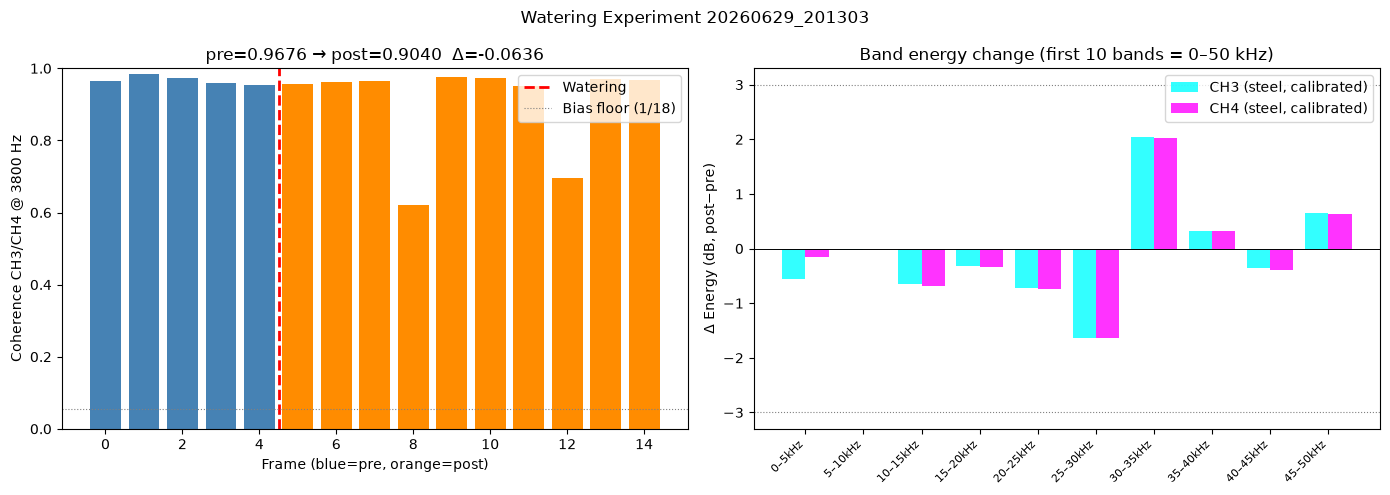

Saved: /media/christoph/some_space/Nextcloud/hs-augsburg/Semester_6/Projekt_I1/projekt_i1/src/characterization/data/watering_experiments/20260629_201303/results.png


In [5]:
# ── 6. Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Watering Experiment {NOW_STR}', fontsize=12)

# Coherence timeseries
ax = axes[0]
all_cohs = [(r['candidate_analysis'].get(CAND_KEY, {}).get('coherence_ch3_ch4', np.nan),
             'steelblue' if i < N_PRE else 'darkorange')
            for i, r in enumerate(pre_records + post_records)]
vals   = [c for c, _ in all_cohs]
colors = [c for _, c in all_cohs]
ax.bar(range(len(vals)), vals, color=colors)
ax.axvline(N_PRE - 0.5, color='red', lw=2, ls='--', label='Watering')
ax.axhline(0.056, color='gray', ls=':', lw=0.8, label='Bias floor (1/18)')
ax.set_xlabel('Frame (blue=pre, orange=post)')
ax.set_ylabel(f'Coherence CH3/CH4 @ {CAND_KEY} Hz')
ax.set_title(f'pre={pre_coh["mean"]:.4f} → post={post_coh["mean"]:.4f}  Δ={h2["delta"]:+.4f}')
ax.legend(); ax.set_ylim(0, 1)

# Band delta CH3 vs CH4 (first 10 bands = 0–50 kHz)
ax2 = axes[1]
n_show = min(10, len(BAND_LABELS))
d3 = [post_bstats['CH3'][b]['mean'] - pre_bstats['CH3'][b]['mean'] for b in range(n_show)]
d4 = [post_bstats['CH4'][b]['mean'] - pre_bstats['CH4'][b]['mean'] for b in range(n_show)]
x  = np.arange(n_show)
ax2.bar(x - 0.2, d3, 0.4, label='CH3 (steel, calibrated)', color='cyan', alpha=0.8)
ax2.bar(x + 0.2, d4, 0.4, label='CH4 (steel, calibrated)', color='magenta', alpha=0.8)
ax2.axhline(0, color='k', lw=0.7)
ax2.axhline(3, color='gray', ls=':', lw=0.8)
ax2.axhline(-3, color='gray', ls=':', lw=0.8)
ax2.set_xticks(x); ax2.set_xticklabels(BAND_LABELS[:n_show], rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Δ Energy (dB, post−pre)')
ax2.set_title('Band energy change (first 10 bands = 0–50 kHz)')
ax2.legend()

plt.tight_layout()
plt.savefig(EXP_DIR / 'results.png', dpi=150)
plt.show()
print(f'Saved: {EXP_DIR}/results.png')


In [6]:
# ── 8. Git commit + push ──────────────────────────────────────────────────────
git_commit_push(EXP_DIR, SESS_EVENTS)
print(f'Experiment {NOW_STR} complete.')

[main 2d55a84] Watering experiment 20260629_201303 [auto]
 7 files changed, 147 insertions(+)
 create mode 100644 src/characterization/data/watering_experiments/20260629_201303/analysis.json
 create mode 100644 src/characterization/data/watering_experiments/20260629_201303/events.jsonl
 create mode 100644 src/characterization/data/watering_experiments/20260629_201303/post_frames.jsonl
 create mode 100644 src/characterization/data/watering_experiments/20260629_201303/pre_frames.jsonl
 create mode 100644 src/characterization/data/watering_experiments/20260629_201303/protocol.json
 create mode 100644 src/characterization/data/watering_experiments/20260629_201303/results.png


Experiment 20260629_201303 complete.


Permission denied, please try again.
Permission denied, please try again.
git@gitlab.informatik.hs-augsburg.de: Permission denied (publickey,password).
fatal: Konnte nicht vom Remote-Repository lesen.

Bitte stellen Sie sicher, dass die korrekten Zugriffsberechtigungen bestehen
und das Repository existiert.
